In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
users = pd.read_csv("users.csv")
subscriptions = pd.read_csv("subscriptions.csv")
payments = pd.read_csv("payments.csv")
events = pd.read_csv("events.csv")

## Convert Date Columns

In [12]:
users["signup_date"] = pd.to_datetime(users["signup_date"])

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

payments["payment_date"] = pd.to_datetime(payments["payment_date"])

events["event_date"] = pd.to_datetime(events["event_date"])

In [13]:
print(users.shape)
print(subscriptions.shape)
print(payments.shape)
print(events.shape)

(10000, 5)
(2480, 6)
(18482, 5)
(200000, 5)


## MRR Growth Trend

In [19]:
payments_success = payments[payments["payment_status"] == "success"].copy()
# Whenever filtering rows, always write .copy().

payments_success["month"] = payments_success["payment_date"].dt.to_period("M")

mrr = payments_success.groupby("month")["amount"].sum().reset_index()

mrr["month"] = mrr["month"].astype(str)

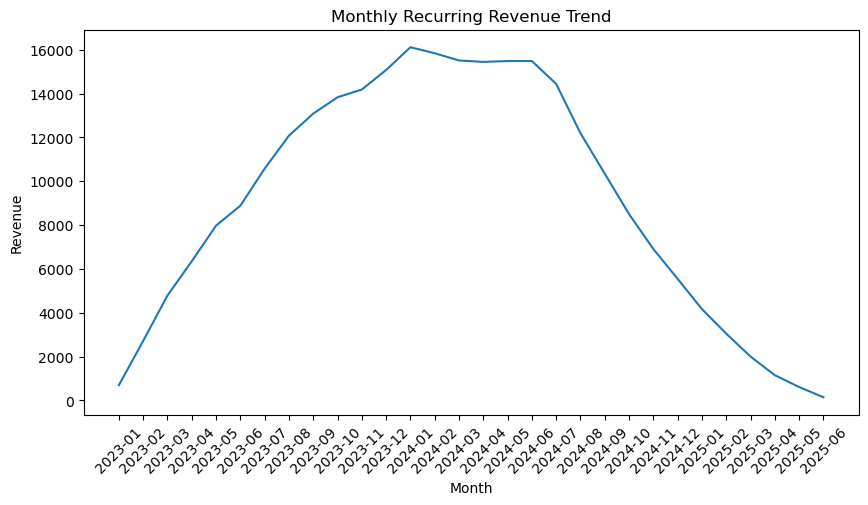

In [24]:
# Plotting

plt.figure(figsize=(10,5))

plt.plot(mrr["month"],mrr["amount"])
plt.xticks(rotation=45)

plt.title("Monthly Recurring Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## CLV Distribution

In [33]:
clv = payments_success.merge(subscriptions, on = "subscription_id")

clv = clv.groupby("user_id")["amount"].sum().reset_index()

clv.rename(columns={"amount":"CLV"},inplace=True)

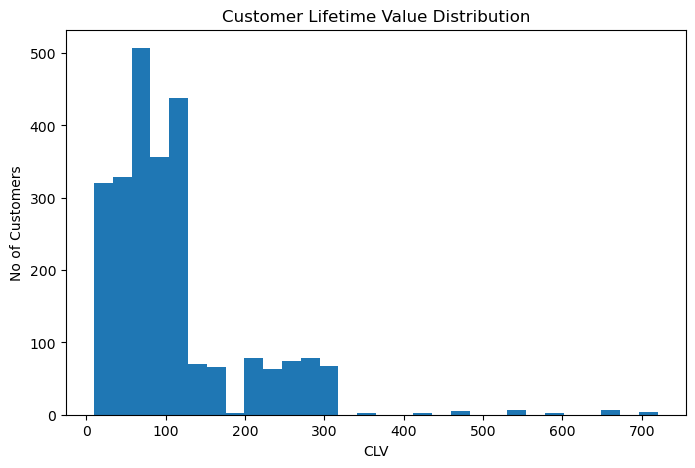

In [40]:
# Plotting

plt.figure(figsize=(8,5))
plt.hist(clv["CLV"],bins=30)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("No of Customers")

plt.show()

# Right-skewed distribution

# Insight : A small segment of high-value users contributes disproportionately to revenue.

## Churn Rate Trend

In [42]:
subscriptions["start_month"] = subscriptions["start_date"].dt.to_period("M")

# size - counts rows in each group
# unstack - pivots the status values into columns
# (fill_value = 0) - ensures missing values become 0 instead of NaN
churn = subscriptions.groupby(["start_month","status"]).size().unstack(fill_value = 0)

churn["churn_rate"] = churn["cancelled"] / (churn["cancelled"] + churn["active"])

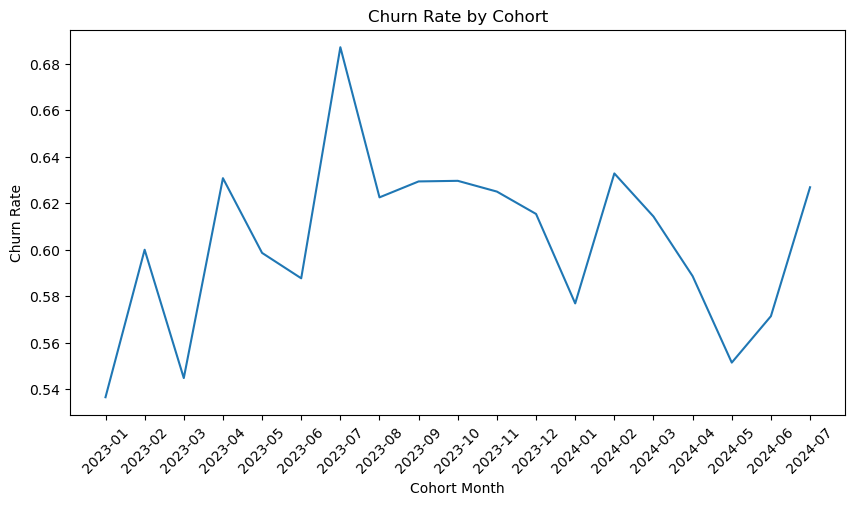

In [43]:
# Plotting

plt.figure(figsize=(10,5))
plt.plot(churn.index.astype(str), churn["churn_rate"])
plt.xticks(rotation=45)

plt.title("Churn Rate by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Churn Rate")

plt.show()

# Churn rate fluctuates between 55–68%, indicating a relatively high churn environment typical of 
# early-stage SaaS products.

## Cohort Retention Heatmap

In [59]:
# cohort month

events["activity_month"] = events["event_date"].dt.to_period("M")
users["cohort_month"] = users["signup_date"].dt.to_period("M")

# merging
cohort = events.merge(users[["user_id","cohort_month"]], on = "user_id")

# Calculate months since signup

cohort["months_since_signup"] = (
                cohort["activity_month"] - cohort["cohort_month"]
).apply(lambda x:x.n)

# Cohort users

cohort_data = cohort.groupby(
            ["cohort_month","months_since_signup"]
)["user_id"].nunique().reset_index()

# Pivot table

cohort_table = cohort_data.pivot(
    index = "cohort_month",
    columns = "months_since_signup",
    values = "user_id"
)

# Normalize by cohort size

cohort_size = users.groupby("cohort_month")["user_id"].nunique()

retention = cohort_table.divide(cohort_size, axis = 0)

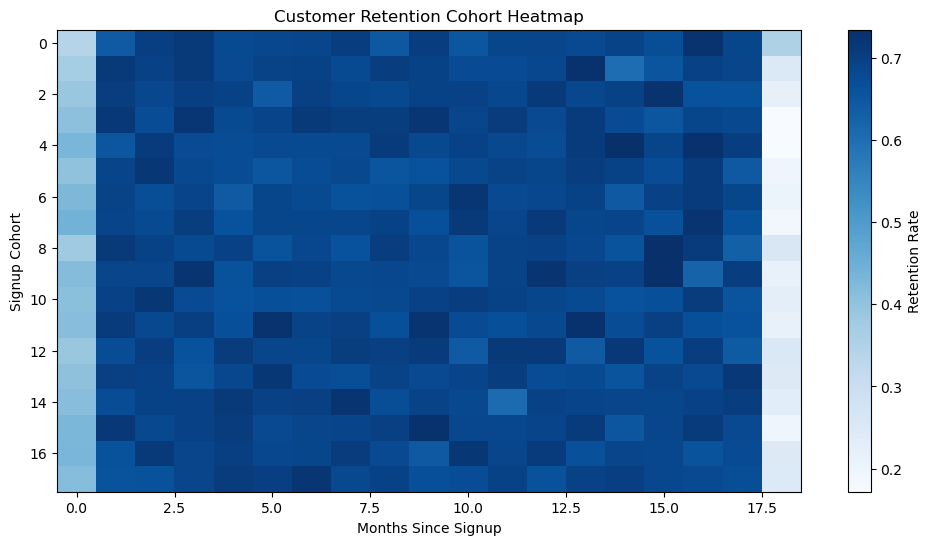

In [60]:
# Plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.imshow(retention, cmap="Blues", aspect="auto")
plt.colorbar(label="Retention Rate")

plt.title("Customer Retention Cohort Heatmap")
plt.xlabel("Months Since Signup")
plt.ylabel("Signup Cohort")

plt.show()